# Lab: Relationships Between Categorical Features

A fictional telecommunications company wants to understand which customer groups had the greatest observed churn percentages. A customer **churned** if they left the company during the previous month.

You will use the reproducible analysis workflow:

1. **Question:** What do we want to learn?
2. **Data:** Which observations and features can help answer it?
3. **Operation:** What should the code select, calculate, or compare?
4. **Check:** Does the result have the expected rows, columns, units, and possible values?
5. **Evidence:** Which result directly answers the question?
6. **Conclusion:** What claim is supported?
7. **Limitation:** What should we avoid concluding?


## Learning goals

By the end of this lab, you should be able to:

- identify a target feature;
- describe the distribution of a categorical target;
- create count, joint-percentage, and conditional-percentage cross-tabs;
- choose a normalization direction from the question;
- check the denominator represented by a percentage;
- refine the visual design of a categorical comparison; and
- distinguish an observed relationship from a causal claim.


## Using AI tools responsibly

You may use an AI tool to ask questions, debug code, or receive feedback. You remain responsible for understanding and checking every submitted response against the notebook's output.

At the end, disclose whether you used AI. If you did, describe one suggestion you evaluated and what you accepted, modified, or rejected. If you did not, state that clearly.


## Dataset

The dataset was prepared from IBM's [Telco Customer Churn sample](https://www.ibm.com/docs/en/cognos-analytics/12.0.x?topic=samples-telco-customer-churn), a fictional telecommunications dataset created for demonstrations. Each row represents one customer. The seven features below were retained from the source and renamed using `snake_case`.

| Feature | Feature type | Description |
| --- | --- | --- |
| `customer_id` | Identifier | Anonymous customer identifier |
| `contract` | Categorical | Month-to-month, one-year, or two-year contract |
| `internet_service` | Categorical | DSL, fiber optic, or no internet service |
| `tech_support` | Categorical | Technical-support status |
| `payment_method` | Categorical | Customer's payment method |
| `paperless_billing` | Categorical | Whether the customer uses paperless billing |
| `churn` | Categorical target | Whether the customer left during the previous month |

The file contains 7,043 customers and no missing values in the retained fields. Because the data describe a fictional company, the results are useful for practicing an analysis workflow but are not evidence about a real company or the telecommunications industry.


## Prepare the notebook

Import Pandas using its conventional alias `pd` and Matplotlib's `pyplot` component using its conventional alias `plt`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt


## Read the data

Read `data/telco_customer_churn.csv` into a DataFrame named `customers`.


In [2]:
customers = pd.read_csv("data/telco_customer_churn.csv")


## Check the data

Display the first five rows.


In [3]:
customers.head()


,customer_id,contract,internet_service,tech_support,payment_method,paperless_billing,churn
0,7590-VHVEG,Month-to-month,DSL,No,Electronic check,Yes,No
1,5575-GNVDE,One year,DSL,No,Mailed check,No,No
2,3668-QPYBK,Month-to-month,DSL,No,Mailed check,Yes,Yes
3,7795-CFOCW,One year,DSL,Yes,Bank transfer (automatic),No,No
4,9237-HQITU,Month-to-month,Fiber optic,No,Electronic check,Yes,Yes


## Check the features

Display a summary that includes the feature names, non-missing counts, and Pandas data storage types.


In [4]:
customers.info()

# Count the missing values in every feature.
missing_counts = customers.isnull().sum()

# Display the missing-value count for every feature.
missing_counts


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   customer_id        7043 non-null   str  
 1   contract           7043 non-null   str  
 2   internet_service   7043 non-null   str  
 3   tech_support       7043 non-null   str  
 4   payment_method     7043 non-null   str  
 5   paperless_billing  7043 non-null   str  
 6   churn              7043 non-null   str  
dtypes: str(7)
memory usage: 385.3 KB


customer_id          0
contract             0
internet_service     0
tech_support         0
payment_method       0
paperless_billing    0
churn                0
dtype: int64

In [5]:
# No additional check needed here; missing_counts above already covers every feature.
missing_counts


customer_id          0
contract             0
internet_service     0
tech_support         0
payment_method       0
paperless_billing    0
churn                0
dtype: int64

A **categorical** feature places observations into groups or labels. A **quantitative** feature records a numerical amount or measurement for which arithmetic is meaningful.


**Complete the table using the results above.** In the data type column, classify each feature as categorical or quantitative. In the data storage type column, record the type reported by Pandas. Different Pandas versions may display text as `str` or `object`.

| Feature | Data type | Data storage type | Missing values |
| --- | --- | --- | ---: |
| `customer_id` | Categorical (identifier) | object | 0 |
| `contract` | Categorical | object | 0 |
| `internet_service` | Categorical | object | 0 |
| `tech_support` | Categorical | object | 0 |
| `payment_method` | Categorical | object | 0 |
| `paperless_billing` | Categorical | object | 0 |
| `churn` | Categorical | object | 0 |


## Identify the target


**Which feature is the target, and what outcome does it represent?**

Your answer: The target is `churn`. It represents whether a customer left the company during the previous month (`Yes`) or stayed (`No`). This is the outcome the company wants to understand and, eventually, reduce.


## Describe the target distribution with counts

Create and display a Series named `churn_counts`.


In [6]:
churn_counts = customers["churn"].value_counts()
churn_counts


churn
No     5174
Yes    1869
Name: count, dtype: int64

**Which target outcome is more frequent?**

Your answer: `No` (customers who did not churn) is more frequent, with 5,174 customers compared to 1,869 who churned.


## Describe the target distribution with relative frequencies

Create and display a Series named `churn_percent`.


In [7]:
churn_percent = customers["churn"].value_counts(normalize=True) * 100
churn_percent


churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

**What percentage of all customers churned?**

Your answer: About 26.5% of all customers churned (1,869 of 7,043 customers).


# Analysis 1: Is churn related to contract type?

Follow the analysis workflow from question through limitation.


**Before calculating a cross-tab, which contract type do you predict had the greatest churn percentage? Explain your prediction.**

Your answer: I predict month-to-month contracts had the greatest churn percentage. Customers on a month-to-month plan face no penalty or long-term commitment for leaving, so they can switch providers or cancel service at any time. Customers locked into one-year or two-year contracts have more incentive (and often an early-termination cost) to stay, so I expect their churn percentage to be lower.


## Step 1: Question


The question is: **Is churn related to contract type?**


## Step 2: Data

The relevant features are `contract` and `churn`. Before calculating percentages, compare the raw counts in their joint distribution.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.

Create and display `contract_churn_counts`, with contract types in the rows and churn outcomes in the columns.


In [8]:
contract_churn_counts = pd.crosstab(customers["contract"], customers["churn"])
contract_churn_counts


churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


**Which contract type has the greatest raw number of customers who churned?**

Your answer: Month-to-month contracts have the greatest raw number of churned customers, at 1,655.


**Do the raw churn counts establish which contract group was most likely to churn? Explain.**

Your answer: No. The raw counts only tell us how many customers churned in each group, not what share of each group churned. Month-to-month contracts also have far more total customers (3,875) than one-year (1,473) or two-year (1,695) contracts, so a larger raw churn count could simply reflect a larger group rather than a higher likelihood of churning. To compare likelihood fairly we need a percentage that accounts for each group's size.


## Step 3: Operation

To compare likelihood fairly, calculate churn percentages within each contract type. First inspect the group totals.

Recreate the contract/churn cross-tab using `margins=True`.


In [9]:
pd.crosstab(customers["contract"], customers["churn"], margins=True)


churn,No,Yes,All
contract,,,
Month-to-month,2220,1655,3875
One year,1307,166,1473
Two year,1647,48,1695
All,5174,1869,7043


**Why do the contract-group totals matter when comparing likelihood?**

Your answer: The group totals are the denominators we need to turn counts into fair, comparable percentages. Without knowing how many customers are in each contract group, a large churn count could just mean a large group, not a high churn rate. The totals let us calculate each group's rate on the same relative scale.


### Joint percentages

Create and display `contract_joint_percent`. All cells together should add to 100%.


In [10]:
contract_joint_percent = pd.crosstab(customers["contract"], customers["churn"], normalize="all") * 100
contract_joint_percent


churn,No,Yes
contract,,
Month-to-month,31.520659,23.498509
One year,18.557433,2.356950
Two year,23.384921,0.681528


## Step 4: Check

Display the sum of every value in `contract_joint_percent`.


In [11]:
contract_joint_percent.values.sum()


np.float64(100.00000000000001)

**What denominator does each joint percentage use?**

Your answer: Each joint percentage uses the total number of customers in the entire dataset (7,043) as its denominator. That is why all six cells in the table add up to 100%.


**Does the joint-percentage table directly answer which contract group was most likely to churn?**

Your answer: No. Joint percentages show what share of the *whole dataset* falls into each contract-and-churn combination, not the churn rate *within* a contract group. For example, month-to-month/churned is the largest single cell partly because month-to-month is the largest contract group overall, not necessarily because it has the highest within-group churn rate. To answer the likelihood question we need conditional percentages calculated within each contract group.


### Conditional percentages

Create `churn_within_contract` so each row describes churn outcomes within one contract type.


In [12]:
churn_within_contract = pd.crosstab(customers["contract"], customers["churn"], normalize="index") * 100
churn_within_contract


churn,No,Yes
contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Check the conditional percentages

Display the sum of each row in `churn_within_contract`.


In [13]:
churn_within_contract.sum(axis=1)


contract
Month-to-month    100.0
One year          100.0
Two year          100.0
dtype: float64

**What should every row add to, and why?**

Your answer: Every row should add to 100%, because each row's percentages are calculated within that contract group (`normalize="index"`). Every customer in a given contract type either churned or did not, so the two conditional percentages in that row must account for the entire group.


**Which contract group had the greatest observed churn percentage? Report the percentage.**

Your answer: Month-to-month contracts had the greatest observed churn percentage, at about 42.7%.


**Was your prediction supported?**

Your answer: Yes. I predicted month-to-month contracts would have the greatest churn percentage, and the conditional percentages confirm this: month-to-month customers churned at about 42.7%, compared to about 11.3% for one-year contracts and about 2.8% for two-year contracts.


## Step 5: Evidence

### Visualize the raw counts

Make a stacked bar chart from `contract_churn_counts`.


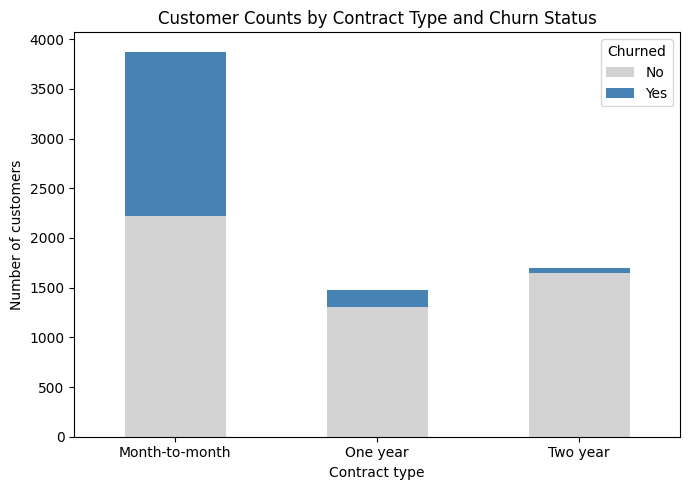

In [14]:
ax = contract_churn_counts.plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(7, 5)
)
ax.set_title("Customer Counts by Contract Type and Churn Status")
ax.set_xlabel("Contract type")
ax.set_ylabel("Number of customers")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Churned", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


### Visualize the conditional percentages

Make a 100% stacked bar chart from `churn_within_contract`. Use:

- `"lightgray"` for customers who did not churn;
- `"steelblue"` for customers who churned;
- a question-focused title;
- descriptive axis labels;
- horizontal x-axis labels; and
- an audience-friendly legend.


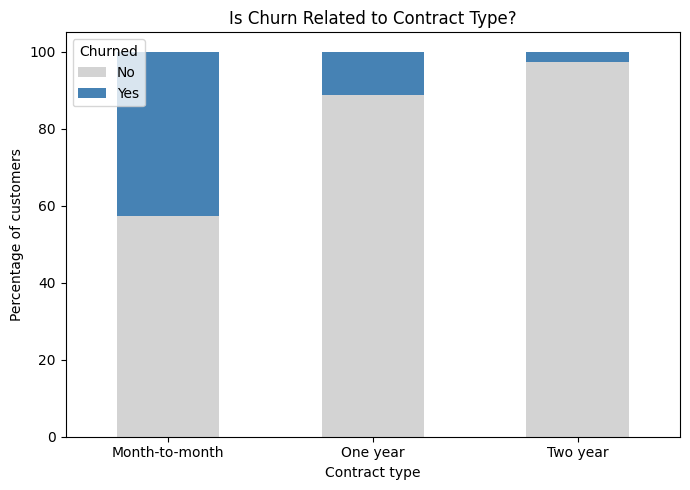

In [15]:
ax = churn_within_contract.plot(
    kind="bar",
    stacked=True,
    color=["lightgray", "steelblue"],
    figsize=(7, 5)
)
ax.set_title("Is Churn Related to Contract Type?")
ax.set_xlabel("Contract type")
ax.set_ylabel("Percentage of customers")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Churned", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


**Which chart answers the likelihood question more clearly: counts or conditional percentages? Explain.**

Your answer: The 100% stacked bar chart of conditional percentages answers the likelihood question more clearly. Because every bar is scaled to the same height (100%), the chart directly shows the *rate* of churn within each contract type, so the bars can be compared fairly regardless of how many customers are in each group. The raw-count chart is dominated by the size of the month-to-month group and makes it harder to see the underlying rate.


## Step 6: Conclusion


**What conclusion about contract type and churn is supported by this sample?**

Your answer: In this sample, contract type is associated with churn: customers on month-to-month contracts churned at a much higher rate (about 42.7%) than customers on one-year (about 11.3%) or two-year (about 2.8%) contracts. Longer contract commitments are associated with lower observed churn.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's contract would cause a change in churn?**

Your answer: This is an observational cross-tabulation, not a controlled experiment. Customers were not randomly assigned to contract types, so contract type is likely tied up with other differences between customers (e.g., how price-sensitive they are, how long they've been a customer, or how satisfied they are with the service) that could also drive churn. Without randomly assigning customers to contracts and controlling for these other factors, we cannot conclude that switching a customer's contract would, by itself, cause their churn behavior to change.


# Analysis 2: Is churn related to payment method?

Apply the same workflow to a second pair of categorical features.


## Step 1: Question


The question is: **Is churn related to payment method?**


## Step 2: Data

Create and display the joint distribution of `payment_method` and `churn` as raw counts. Name it `payment_churn_counts`.

Create and display `payment_churn_counts`.


In [16]:
payment_churn_counts = pd.crosstab(customers["payment_method"], customers["churn"])
payment_churn_counts


churn,No,Yes
payment_method,,
Bank transfer (automatic),1286,258
Credit card (automatic),1290,232
Electronic check,1294,1071
Mailed check,1304,308


## Step 3: Operation

Create and display `churn_within_payment`.


In [17]:
churn_within_payment = pd.crosstab(customers["payment_method"], customers["churn"], normalize="index") * 100
churn_within_payment


churn,No,Yes
payment_method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


## Step 4: Check

Display the sum of every row in `churn_within_payment`.


In [18]:
churn_within_payment.sum(axis=1)


payment_method
Bank transfer (automatic)    100.0
Credit card (automatic)      100.0
Electronic check             100.0
Mailed check                 100.0
dtype: float64

**Which payment-method group had the greatest observed churn percentage? Report the percentage.**

Your answer: Customers who pay by electronic check had the greatest observed churn percentage, at about 45.3%.


## Step 5: Evidence

Make a 100% stacked bar chart. Choose two readable colors that are different from the `"lightgray"` and `"steelblue"` used in the contract chart. Use the same color consistently for each outcome throughout this chart and include audience-friendly labels.


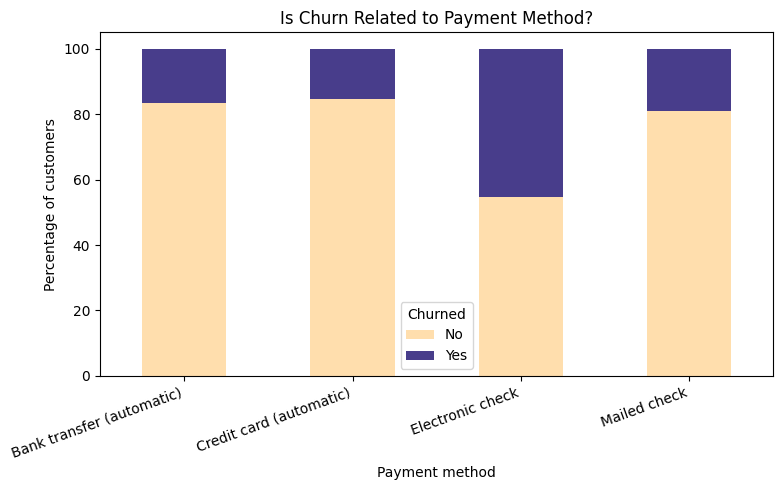

In [19]:
ax = churn_within_payment.plot(
    kind="bar",
    stacked=True,
    color=["navajowhite", "darkslateblue"],
    figsize=(8, 5)
)
ax.set_title("Is Churn Related to Payment Method?")
ax.set_xlabel("Payment method")
ax.set_ylabel("Percentage of customers")
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Churned", labels=["No", "Yes"])
plt.tight_layout()
plt.show()


## Step 6: Conclusion


**What conclusion about payment method and churn is supported by the sample? Include the percentage that provides your strongest evidence.**

Your answer: In this sample, payment method is associated with churn. Customers who pay by electronic check churned at a much higher rate (about 45.3%) than customers using bank transfer (about 16.7%), credit card (about 15.2%), or mailed check (about 19.1%). Electronic check stands out as the payment method most strongly associated with churn.


## Step 7: Limitation


**Why does this analysis not prove that changing a customer's payment method would cause a change in churn?**

Your answer: This is observational data, not an experiment: customers chose their own payment method rather than being randomly assigned one. Customers who pay by electronic check may differ from other customers in other ways (e.g., contract type, how engaged they are with account management, or general dissatisfaction) that could actually be driving the churn, and payment method could simply be correlated with those underlying factors. We cannot conclude that switching a customer's payment method would, on its own, change their likelihood of churning.


## AI-use reflection


State whether you used an AI tool. If you did, identify one suggestion you checked and explain what you accepted, modified, or rejected. If you did not, state that you did not use one.

Your answer: For this assignment I used Claude to ask it one question: "When would I want to normalize by columns instead of by rows in a cross-tab?". This was useful for me to understanding why normalize="index" was the right choice here instead of normalize="columns".


## Submission checklist

- Run every code cell from top to bottom.
- Use all requested object names.
- Complete every written-response cell.
- Check that numerical claims match the output.
- Use named colors and audience-friendly labels.
- Keep code, figures, and written answers neat and easy to read.
- Distinguish an observed relationship from a causal claim.
- Complete the AI-use reflection.
- Submit the completed notebook by the deadline.
